In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict


In [2]:
load_dotenv()
model=ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
class UpscState(TypedDict):
    essay:str
    cot:int
    doa:int
    language:int
    summary:str

In [16]:
def get_cot(state:UpscState)->UpscState:
    essay=state['essay']
    prompt=f"You are a checker of UPSC paper. Your task is to evaluate essays on the basis of Clarity of thoughts and give the score from 0 to 10 and an honest feedback regarding the essay based on clarity of thoughts. Evaluate this essay:{essay}. Return the feedback and score "
    cot=model.invoke(prompt).content
    return{"cot":cot}
 
def get_doa(state:UpscState)->UpscState:
    essay=state['essay']
    prompt=f"You are a checker of UPSC paper. Your task is to evaluate essays on the basis of Detail of analysis and give the score from 0 to 10 and an honest feedback regarding the essay based on Detail of analysis. Evaluate this essay:{essay}. Return the feedback and score "
    doa=model.invoke(prompt).content
    return {"doa":doa}

def get_language(state:UpscState)->UpscState:
    essay=state['essay']
    prompt=f"You are a checker of UPSC paper. Your task is to evaluate essays on the basis of grip on the language and give the score from 0 to 10 and an honest feedback regarding the essay based on Detail of analysis. Evaluate this essay:{essay}. Return the feedback and score."
    language=model.invoke(prompt).content
    return {"language":language}
    

In [17]:
def get_summary(state:UpscState)->UpscState:
    prompt=f"""You are a summarizer model whose task is to summarise the scores and feedback from Clarity of thoughts(cot),Detail of analysis(doa) and grip on the language(gol). You also need to give the total average of the scores of them. use this json format to give the output: Total score: <total score>
    feedback:<feedback summary>.
    this is the given input to you:-
    cot:{state['cot']},
    doa:{state['doa']},
    gol:{state['language']}
    """
    res=model.invoke(prompt).content
    return {"summary":res}


In [18]:
state=StateGraph(UpscState)

# Nodes
state.add_node("get_cot",get_cot)
state.add_node("get_doa",get_doa)
state.add_node("get_language",get_language)
state.add_node("get_summary",get_summary)

# edges
state.add_edge(START,"get_language")
state.add_edge(START,"get_doa")
state.add_edge(START,"get_cot")

state.add_edge("get_cot","get_summary")
state.add_edge("get_language","get_summary")
state.add_edge("get_doa","get_summary")

state.add_edge("get_summary",END)

# compile
workflow=state.compile()

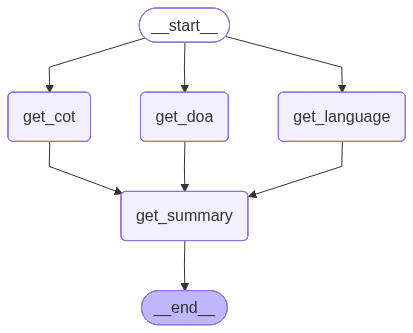

In [19]:
workflow

In [20]:
inital_state={"essay":"""Artificial Intelligence (AI) refers to the ability of machines to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, and decision-making. From its early conceptual roots in the mid-20th century to its rapid advancements today, AI has transformed from a theoretical idea into a powerful technology shaping modern society.
One of the key aspects of AI is its ability to learn from data. Through techniques such as machine learning and deep learning, computers can identify patterns, make predictions, and improve their performance over time without being explicitly programmed. This has enabled applications like speech recognition, image classification, and recommendation systems, which are now part of everyday life. Virtual assistants, navigation apps, and streaming platforms all rely heavily on AI to enhance user experience.
AI is widely used across various industries. In healthcare, it helps doctors diagnose diseases, analyze medical images, and develop personalized treatment plans. In finance, AI is used for fraud detection, risk assessment, and algorithmic trading. The transportation sector benefits from AI through self-driving cars and traffic optimization systems. Even in agriculture, AI assists in crop monitoring and yield prediction, helping farmers make better decisions.
Despite its many advantages, AI also raises important ethical and social concerns. Issues such as data privacy, job displacement, and algorithmic bias have become significant topics of discussion. As machines become more capable, there is a growing need to ensure that AI systems are transparent, fair, and aligned with human values. Governments and organizations are working to establish guidelines and regulations to address these challenges.
In conclusion, Artificial Intelligence is a transformative force that is reshaping the way we live and work. While it offers immense potential to improve efficiency and solve complex problems, it also requires careful management to mitigate its risks. As AI continues to evolve, it is essential for society to strike a balance between innovation and responsibility, ensuring that this powerful technology benefits all of humanity."""}
workflow.invoke(inital_state)

{'essay': 'Artificial Intelligence (AI) refers to the ability of machines to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, and decision-making. From its early conceptual roots in the mid-20th century to its rapid advancements today, AI has transformed from a theoretical idea into a powerful technology shaping modern society.\nOne of the key aspects of AI is its ability to learn from data. Through techniques such as machine learning and deep learning, computers can identify patterns, make predictions, and improve their performance over time without being explicitly programmed. This has enabled applications like speech recognition, image classification, and recommendation systems, which are now part of everyday life. Virtual assistants, navigation apps, and streaming platforms all rely heavily on AI to enhance user experience.\nAI is widely used across various industries. In healthcare, it helps doctors diagnose diseases, analyze m